In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Project Path Setup
from setup_project_path import (
    check_and_add_project_path,
)  # Script to check and add project path
check_and_add_project_path()
from src.AAA.baryrat import aaa
from src.kernel_params.kernel_params import KernelParams
from src.kernel_matrix.kernel_matrix import KernelMatrix
from src.spec_dens.spec_dens import spec_dens_gapless

Project path successfully added.


In [2]:

#set up parameters for specified spectral densities 
spec_dens = lambda omega: np.sqrt(1 - omega**2) * 1/(1 + np.exp(100* (abs(omega) -1)))
beta = 0
params = KernelParams(spec_dens = spec_dens, n = 500, m = 200, N_max = 120, h = 0.01, beta = beta, phi = 0)

#create KernelMatrix object with specified parameters which we will use as reference 
K = KernelMatrix(**params.params)

#explicitly get the fine frequency grid
fine_grid, _, Jacobian = K._initialize_fine_grid()

# frequency points in complex plane
Z = fine_grid * np.exp(1.0j * K.phi) 
# function values on the rotated contour, determined by product of spectral density and Fermi Dirac distribution and Jacobian factor
F = K.kernel[0,:] 

print("parameters: ")
#h
print("h: ", params.get_param("h"))
#m
print("m: ", params.get_param("m"))
#n
print("n: ", params.get_param("n"))
#N_max
print("N_max: ", params.get_param("N_max"))
#delta_t
print("delta_t: ", params.get_param("delta_t"))
#beta
print("beta: ", params.get_param("beta"))

print(abs(Z))
#perform AAA algorithm on spectral density multiplied with Fermi-Dirac distribution
r, errors = aaa(Z = Z, F = F, return_errors=True)
poles, residues = r.polres()
print(len(poles), len(residues))

parameters: 
h:  0.01
m:  200
n:  500
N_max:  120
delta_t:  0.1
beta:  0
[6.73794700e-03 6.80566449e-03 6.87406256e-03 6.94314803e-03
 7.01292783e-03 7.08340893e-03 7.15459837e-03 7.22650328e-03
 7.29913085e-03 7.37248833e-03 7.44658307e-03 7.52142247e-03
 7.59701403e-03 7.67336529e-03 7.75048389e-03 7.82837755e-03
 7.90705405e-03 7.98652127e-03 8.06678714e-03 8.14785970e-03
 8.22974705e-03 8.31245738e-03 8.39599897e-03 8.48038016e-03
 8.56560940e-03 8.65169520e-03 8.73864619e-03 8.82647104e-03
 8.91517855e-03 9.00477758e-03 9.09527710e-03 9.18668616e-03
 9.27901389e-03 9.37226953e-03 9.46646240e-03 9.56160193e-03
 9.65769763e-03 9.75475910e-03 9.85279606e-03 9.95181831e-03
 1.00518357e-02 1.01528584e-02 1.02548963e-02 1.03579597e-02
 1.04620589e-02 1.05672044e-02 1.06734066e-02 1.07806761e-02
 1.08890237e-02 1.09984602e-02 1.11089965e-02 1.12206438e-02
 1.13334132e-02 1.14473159e-02 1.15623633e-02 1.16785670e-02
 1.17959385e-02 1.19144897e-02 1.20342323e-02 1.21551783e-02
 1.22773399e

/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/julianthoenniss/Documents/PhD/code/channel_IF/RealTimeID/ModesEnv/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


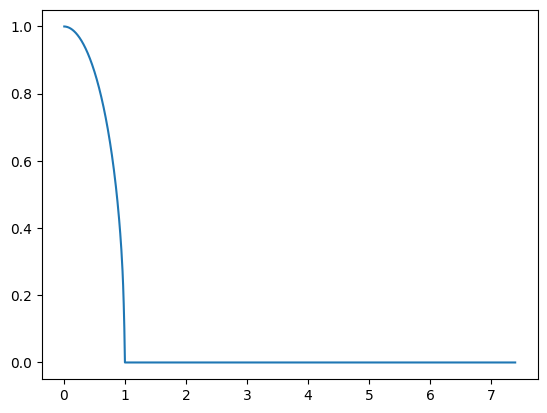

In [3]:
plt.figure()
plt.plot(Z, spec_dens(Z))

[1.09936071 1.06606956 1.06375431 1.04896661 1.0337539  1.03513306
 1.01732207 1.02814442 1.00998995 1.0262015  1.02701439 1.00773473
 1.02890456 1.00781072 1.03104102 1.00866719 1.03313493 1.0095815
 1.03269796 1.01027317 1.02350441 1.01225671 1.01054341 1.00443146
 0.98482319 1.00702136 1.00161204 1.00049335 1.00188556 1.00147079
 0.99941903 0.99888562 0.99988526 1.00008841 1.00001984]


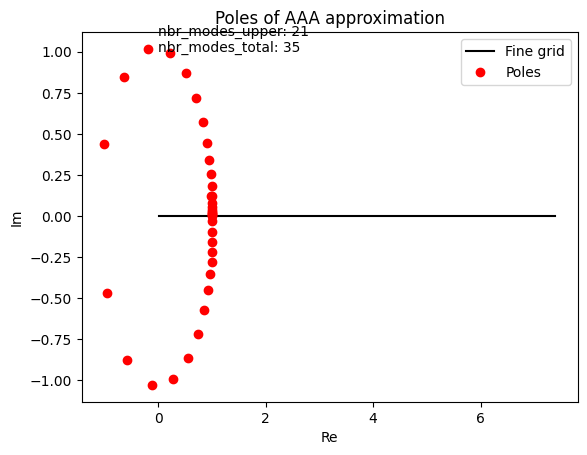

In [4]:
#plot the poles in the complex plane
print(abs(poles))
plt.figure()
plt.plot(Z.real, Z.imag, 'k', label = 'Fine grid')
plt.plot(poles.real, poles.imag, 'ro', label = 'Poles')
plt.title('Poles of AAA approximation')
plt.legend()
plt.xlabel('Re')
plt.ylabel('Im')
plt.text(0,1, 'nbr_modes_upper: ' + str(len(poles[poles.imag > 0])) + '\n' + 'nbr_modes_total: ' + str(len(poles)))
plt.show()


Text(0, 0.5, 'r_check')

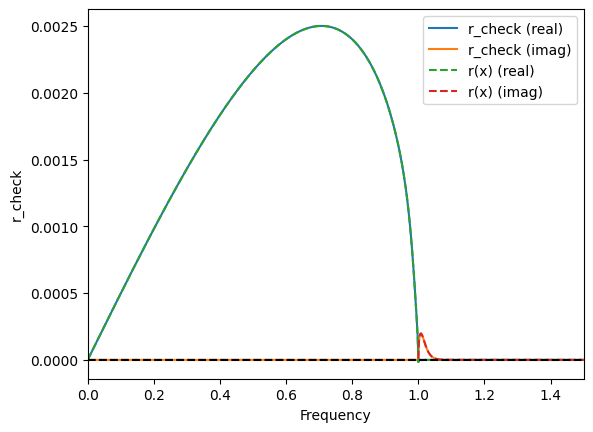

In [11]:
#check that sum over residues divided by poles gives r(z)

#r_check = lambda x: np.sum([res / (x - pole) for res, pole in zip(residues, poles) if abs(pole) < 1.e1])

def r_check(x):
    val = 0
    for i in range(len(poles)):
        val += residues[i] / (x - poles[i])
    return val
        

x_range = np.linspace(0,20,10000)

vals = np.array([r_check(x) for x in x_range])


plt.figure()
plt.plot(x_range, vals.real, label = 'r_check (real)')
plt.plot(x_range, vals.imag, label = 'r_check (imag)')
plt.plot(x_range, np.real(r(x_range)), label = 'r(x) (real)', linestyle = '--')
plt.plot(x_range, np.imag(r(x_range)), label = 'r(x) (imag)', linestyle = '--')
#for i in range(len(poles)):
#    plt.plot(x_range, residues[i] / (x_range - poles[i]), label = 'residue ' + str(i))
plt.hlines(0, 0, 10, color = 'k', linestyle = '--')
plt.legend()
plt.xlim(0, 1.5)
plt.xlabel('Frequency')
plt.ylabel('r_check')

Text(0, 0.5, 'Error')

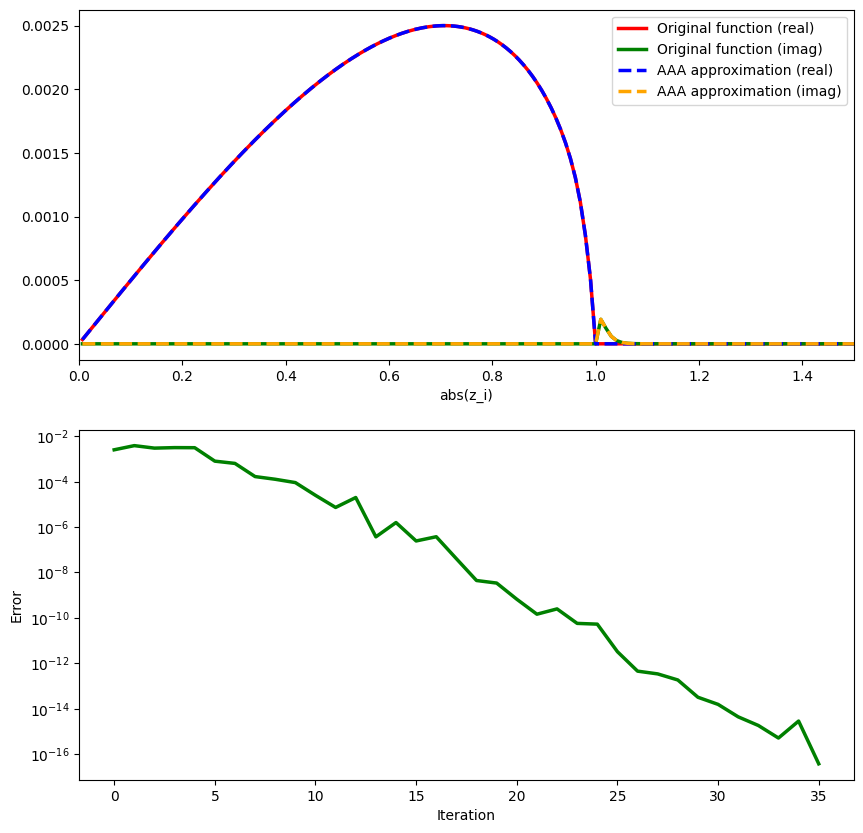

In [6]:

#check that the function is correctly approximated

F_AAA = r(Z) #values computed based on the AAA approximation

#figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
#first plot original and reconstructed function
axs[0].plot(abs(Z), F.real, label = 'Original function (real)', linewidth = 2.5, color = 'red')
axs[0].plot(abs(Z), F.imag, label = 'Original function (imag)', linewidth = 2.5, color = 'green')
axs[0].plot(abs(Z), F_AAA.real, label = 'AAA approximation (real)', linestyle = '--', linewidth = 2.5, color = 'blue')
axs[0].plot(abs(Z), F_AAA.imag, label = 'AAA approximation (imag)', linestyle = '--', linewidth = 2.5, color = 'orange')
#f_analyt = 1/(1+np.exp(-beta* Z))  * spec_dens(Z) * Jacobian * np.exp(1.j * np.pi/4)
#axs[0].plot(abs(Z), np.real(f_analyt), label = 'Explicit formula', linestyle = 'dotted', linewidth = 2.5, color = 'black')
axs[0].legend()
axs[0].set_xlabel('abs(z_i)')
axs[0].set_xlim(0, 1.5)
#axs[0].text(0, 1.5, 'f(x) = n(x) * Gamma(x) * Jac(x)\n' +"with " + 'Gamma(x) = sqrt(100 - omega**2)', fontsize = 12)
#plot the error as function of iteration
axs[1].plot(errors, label = 'Error', linewidth = 2.5, color = 'green')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Error')



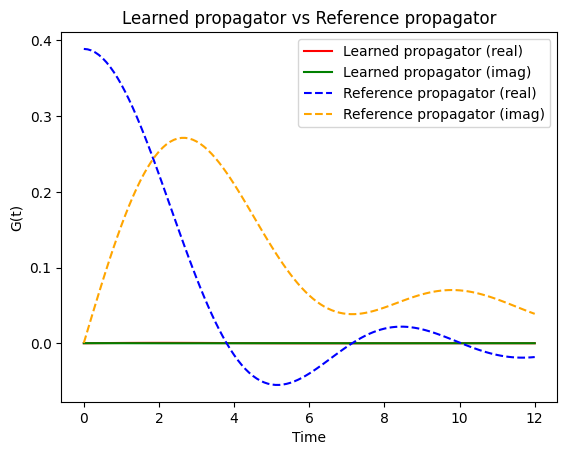

In [13]:
#check that "learned propagator is close to the reference propagator"
residues_upper = residues[poles.imag > 0]
poles_upper = poles[poles.imag > 0]

#sum over all modes
G_learned = np.sum(residues_upper * np.exp(1.j * poles_upper * K.times[:,np.newaxis]), axis= 1)

G_ref = K.discrete_integral()

#plot the learned propagator and the reference propagator
plt.plot(K.times, G_learned.real, label='Learned propagator (real)', color = 'red')
plt.plot(K.times, G_learned.imag, label='Learned propagator (imag)', color = 'green')
plt.plot(K.times, G_ref.real, label='Reference propagator (real)', color = 'blue', linestyle = '--')
plt.plot(K.times, G_ref.imag, label='Reference propagator (imag)', color = 'orange', linestyle = '--')
plt.legend()
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Learned propagator vs Reference propagator')
plt.show()
